In [1]:
!pip install segmentation-models-pytorch torch torchmetrics albumentations

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.3/121.3 kB 4.9 MB/s eta 0:00:00
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16424 sha256=de17ede8f8adf53095adac5f710814e2ecc992ae15e70b84c685d5d485d834f9
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60944 sha256=69680c91f49a0fd3f8aa01446608d97e5fef5a4b874db3e5c9c67a1eadf92312
  Stored in directory: /root/.cache/pip/wheels/35/cb/a5/8f534c60142835bfc889f9a482e4a67e0b817032d9c6883b64
Successfully built efficientnet-pytorch pretrainedmodels


In [2]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from torchmetrics.classification import BinaryJaccardIndex, BinaryAccuracy
from torchmetrics import Dice
import torchvision.models as models
import torch.nn.functional as F
from torch.nn import init

import segmentation_models_pytorch as smp

In [3]:
# Dataset paths
C_image_path = "/kaggle/input/pulmonary-chest-xray-abnormalities/ChinaSet_AllFiles/ChinaSet_AllFiles/CXR_png/"
C_masks_path = "/kaggle/input/shcxr-lung-mask/mask/"

# Output directories
BASE_OUTPUT_DIR = "/kaggle/working/segmentation"
TRAIN_IMAGE_DIR = os.path.join(BASE_OUTPUT_DIR, "train_images")
TRAIN_MASK_DIR  = os.path.join(BASE_OUTPUT_DIR, "train_masks")
TEST_IMAGE_DIR  = os.path.join(BASE_OUTPUT_DIR, "test_images")
TEST_MASK_DIR   = os.path.join(BASE_OUTPUT_DIR, "test_masks")

for d in [TRAIN_IMAGE_DIR, TRAIN_MASK_DIR, TEST_IMAGE_DIR, TEST_MASK_DIR]:
    os.makedirs(d, exist_ok=True)

In [4]:
# List and sort image files
image_files = sorted([f for f in os.listdir(C_image_path) if f.endswith('.png')])
print("Number of Shenzhen images:", len(image_files))
# Full paths for image files
image_files_full = [os.path.join(C_image_path, f) for f in image_files]

Number of Shenzhen images: 662


In [5]:
# Shuffle and split 80% train, 20% test.
random.shuffle(image_files_full)
split_index = int(len(image_files_full) * 0.8)
train_files = image_files_full[:split_index]
test_files  = image_files_full[split_index:]

print("Number of training images:", len(train_files))
print("Number of test images:", len(test_files))

Number of training images: 529
Number of test images: 133


In [6]:
# Process each image (read, resize, binarize)

IMG_SIZE = (512, 512)
skipped = 0

for img_file in image_files_full:
    base_file = os.path.basename(img_file)
    # Determine corresponding mask filename.
    if "_mask" not in base_file:
        filename, ext = os.path.splitext(base_file)
        mask_filename = f"{filename}_mask{ext}"
    else:
        mask_filename = base_file
    mask_file = os.path.join(C_masks_path, mask_filename)
    
    image = cv2.imread(img_file)
    mask  = cv2.imread(mask_file, cv2.IMREAD_GRAYSCALE)
    
    if image is None or mask is None:
        skipped += 1
        continue
    
    image_resized = cv2.resize(image, IMG_SIZE)
    mask_resized  = cv2.resize(mask, IMG_SIZE)
    
    # Binarize mask
    _, mask_binary = cv2.threshold(mask_resized, 128, 255, cv2.THRESH_BINARY)
    
    if img_file in train_files:
        cv2.imwrite(os.path.join(TRAIN_IMAGE_DIR, base_file), image_resized)
        cv2.imwrite(os.path.join(TRAIN_MASK_DIR, mask_filename), mask_binary)
    else:
        cv2.imwrite(os.path.join(TEST_IMAGE_DIR, base_file), image_resized)
        cv2.imwrite(os.path.join(TEST_MASK_DIR, mask_filename), mask_binary)
print(f"{skipped} images skipped.")

96 images skipped.


In [7]:
# Check count for each file (diagnostic).
train_image_count = len(os.listdir(TRAIN_IMAGE_DIR))
train_mask_count  = len(os.listdir(TRAIN_MASK_DIR))
test_image_count  = len(os.listdir(TEST_IMAGE_DIR))
test_mask_count   = len(os.listdir(TEST_MASK_DIR))

print("Training Images:", train_image_count)
print("Training Masks :", train_mask_count)
print("Testing Images :", test_image_count)
print("Testing Masks  :", test_mask_count)

Training Images: 448
Training Masks : 448
Testing Images : 118
Testing Masks  : 118


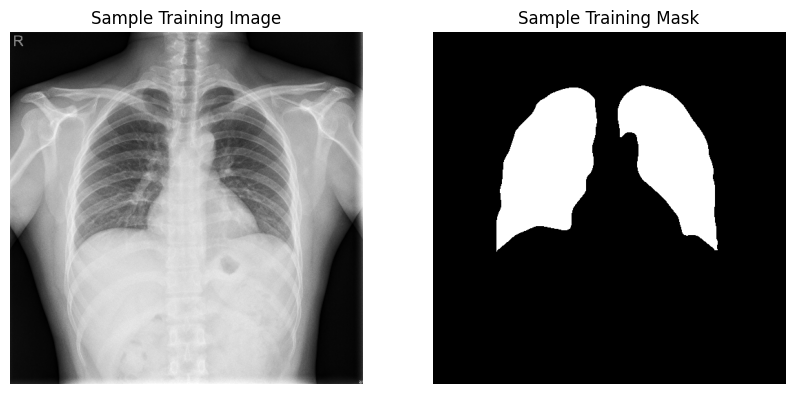

Unique pixel values in one training mask (CHNCXR_0532_1_mask.png): [  0 255]


In [8]:
# Display one random sample from training.
if train_image_count > 0:
    sample_train_image_name = random.choice(os.listdir(TRAIN_IMAGE_DIR))
    sample_train_image_path = os.path.join(TRAIN_IMAGE_DIR, sample_train_image_name)
    filename, ext = os.path.splitext(sample_train_image_name)
    if "_mask" not in sample_train_image_name:
        sample_train_mask_name = f"{filename}_mask{ext}"
    else:
        sample_train_mask_name = sample_train_image_name
    sample_train_mask_path = os.path.join(TRAIN_MASK_DIR, sample_train_mask_name)
    
    sample_train_image = cv2.imread(sample_train_image_path)
    sample_train_mask  = cv2.imread(sample_train_mask_path, cv2.IMREAD_GRAYSCALE)
    
    if sample_train_image is not None and sample_train_mask is not None:
        plt.figure(figsize=(10,5))
        plt.subplot(1,2,1)
        plt.imshow(cv2.cvtColor(sample_train_image, cv2.COLOR_BGR2RGB))
        plt.title("Sample Training Image")
        plt.axis("off")
        plt.subplot(1,2,2)
        plt.imshow(sample_train_mask, cmap="gray")
        plt.title("Sample Training Mask")
        plt.axis("off")
        plt.show()
    else:
        print("Could not load training sample image/mask.")
else:
    print("No training images found.")

# Check unique pixel values in one training mask.
if train_mask_count > 0:
    some_mask_file = os.path.join(TRAIN_MASK_DIR, os.listdir(TRAIN_MASK_DIR)[0])
    some_mask = cv2.imread(some_mask_file, cv2.IMREAD_GRAYSCALE)
    if some_mask is not None:
        unique_vals = np.unique(some_mask)
        print(f"Unique pixel values in one training mask ({os.path.basename(some_mask_file)}):", unique_vals)
    else:
        print("Could not load a training mask for pixel value check.")


In [9]:
img_transform = Compose([
    Resize(IMG_SIZE),
    ToTensor(),  # Converts the PIL image from [0,255] to [0,1] as a tensor.
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

mask_transform = Compose([
    Resize(IMG_SIZE),
    ToTensor()
])

In [10]:
def load_dataset(image_dir, mask_dir):
    image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])
    images = []
    masks = []
    for f in image_files:
        image_path = os.path.join(image_dir, f)
        # Construct the corresponding mask filename:
        if "_mask" not in f:
            filename, ext = os.path.splitext(f)
            mask_filename = f"{filename}_mask{ext}"
        else:
            mask_filename = f
        mask_path = os.path.join(mask_dir, mask_filename)
        # Load image and mask.
        image = Image.open(image_path).convert("RGB")
        mask  = Image.open(mask_path).convert("L")
        image = img_transform(image)
        mask = mask_transform(mask)
        mask = (mask > 0.5).float()  # Binarize mask.
        images.append(image)
        masks.append(mask)
    images_tensor = torch.stack(images)
    masks_tensor = torch.stack(masks)
    return TensorDataset(images_tensor, masks_tensor)

In [11]:
train_dataset = load_dataset(TRAIN_IMAGE_DIR, TRAIN_MASK_DIR)
val_dataset   = load_dataset(TEST_IMAGE_DIR, TEST_MASK_DIR)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ChannelAttention(nn.Module):
    def __init__(self, channel, reduction=16):
        super(ChannelAttention, self).__init__()
        self.maxpool = nn.AdaptiveMaxPool2d(1)  # Get maximum values across spatial dims.
        self.avgpool = nn.AdaptiveAvgPool2d(1)  # Get average values.
        self.se = nn.Sequential(
            nn.Conv2d(channel, channel // reduction, kernel_size=1, bias=False),  # Reduction
            nn.ReLU(),
            nn.Conv2d(channel // reduction, channel, kernel_size=1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        max_result = self.maxpool(x)
        avg_result = self.avgpool(x)
        max_out = self.se(max_result)
        avg_out = self.se(avg_result)
        output = self.sigmoid(max_out + avg_out)
        return output

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        max_result, _ = torch.max(x, dim=1, keepdim=True)
        avg_result = torch.mean(x, dim=1, keepdim=True)
        result = torch.cat([max_result, avg_result], dim=1)
        output = self.conv(result)
        output = self.sigmoid(output)
        return output

class CBAMBlock(nn.Module):
    def __init__(self, channel=512, reduction=16, kernel_size=7):
        super(CBAMBlock, self).__init__()
        self.ca = ChannelAttention(channel=channel, reduction=reduction)
        self.sa = SpatialAttention(kernel_size=kernel_size)
    
    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                init.kaiming_normal_(m.weight, mode='fan_out')
                if m.bias is not None:
                    init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                init.constant_(m.weight, 1)
                init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                init.normal_(m.weight, std=0.001)
                if m.bias is not None:
                    init.constant_(m.bias, 0)
    
    def forward(self, x):
        residual = x
        out = x * self.ca(x)
        out = out * self.sa(out)
        return out + residual
        
# CBAM implementation
class UNetResNet34_CBAM(nn.Module):
    def __init__(self, n_classes):
        super(UNetResNet34_CBAM, self).__init__()
        # Encoder: Pretrained ResNet34 backbone.
        resnet = models.resnet34(pretrained=True)
        self.layer0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)  # [B, 64, H/2, W/2]
        self.layer1 = nn.Sequential(resnet.maxpool, resnet.layer1)           # [B, 64, H/4, W/4]
        self.layer2 = resnet.layer2  # [B, 128, H/8, W/8]
        self.layer3 = resnet.layer3  # [B, 256, H/16, W/16]
        self.layer4 = resnet.layer4  # [B, 512, H/32, W/32] -> Bottleneck
        
        # CBAM blocks for skip connections.
        self.cbam0 = CBAMBlock(channel=64, reduction=16, kernel_size=7)   # For layer0
        self.cbam1 = CBAMBlock(channel=64, reduction=16, kernel_size=7)   # For layer1
        self.cbam2 = CBAMBlock(channel=128, reduction=16, kernel_size=7)  # For layer2
        self.cbam3 = CBAMBlock(channel=256, reduction=16, kernel_size=7)  # For layer3
        # No CBAM block applied on bottleneck (layer4)
        
        # Decoder Blocks: Using transposed convolutions and conv layers.
        self.upconv4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.decoder3 = nn.Sequential(
            nn.Conv2d(256 + 256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder2 = nn.Sequential(
            nn.Conv2d(128 + 128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.upconv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder1 = nn.Sequential(
            nn.Conv2d(64 + 64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.upconv1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.decoder0 = nn.Sequential(
            nn.Conv2d(64 + 64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.final_conv = nn.Conv2d(64, n_classes, kernel_size=1)
        
    def forward(self, x):
        # Encoder forward pass.
        x0 = self.layer0(x)    # [B, 64, H/2, W/2]
        x1 = self.layer1(x0)   # [B, 64, H/4, W/4]
        x2 = self.layer2(x1)   # [B, 128, H/8, W/8]
        x3 = self.layer3(x2)   # [B, 256, H/16, W/16]
        x4 = self.layer4(x3)   # [B, 512, H/32, W/32]
        
        # Apply CBAM on skip connections.
        x0_att = self.cbam0(x0)
        x1_att = self.cbam1(x1)
        x2_att = self.cbam2(x2)
        x3_att = self.cbam3(x3)
        
        # Decoder forward pass with CBAM-enhanced skip connections.
        d4 = self.upconv4(x4)                    # Upsample [B, 256, H/16, W/16]
        d4 = torch.cat([d4, x3_att], dim=1)        # Concatenation [B, 256+256, H/16, W/16]
        d4 = self.decoder3(d4)
        
        d3 = self.upconv3(d4)                     # Upsample [B, 128, H/8, W/8]
        d3 = torch.cat([d3, x2_att], dim=1)        # Concatenation [B, 128+128, H/8, W/8]
        d3 = self.decoder2(d3)
        
        d2 = self.upconv2(d3)                     # Upsample [B, 64, H/4, W/4]
        d2 = torch.cat([d2, x1_att], dim=1)        # Concatenation [B, 64+64, H/4, W/4]
        d2 = self.decoder1(d2)
        
        d1 = self.upconv1(d2)                     # Upsample [B, 64, H/2, W/2]
        d1 = torch.cat([d1, x0_att], dim=1)        # Concatenation [B, 64+64, H/2, W/2]
        d1 = self.decoder0(d1)
        
        out = self.final_conv(d1)                 # [B, n_classes, H/2, W/2]
        # **MODIFICATION:** Upsample to match input resolution (512x512)
        out = F.interpolate(out, scale_factor=2, mode='bilinear', align_corners=True)
        return out

model = UNetResNet34_CBAM(n_classes=1)
model = model.to(device)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 199MB/s]


In [13]:
# Loss function
loss_fn = smp.losses.DiceLoss(mode='binary')

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Metrics
iou_metric = BinaryJaccardIndex(threshold=0.5).to(device)
accuracy_metric = BinaryAccuracy(threshold=0.5).to(device)
dice_metric = Dice(threshold=0.5).to(device)

In [14]:
# Training hyperparameters.
patience = 5
best_val_loss = float('inf')
epochs_without_improvement = 0
num_epochs = 25

score_history = {
    'epoch': [],
    'train_loss': [],
    'val_loss': [],
    'val_iou': [],
    'val_accuracy': [],
    'val_dice': []
}

# Training loop.
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)  # Already in [0,1] and shape [B,1,H,W]
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    avg_train_loss = train_loss / len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    # Reset metrics before validation.
    iou_metric.reset()
    accuracy_metric.reset()
    dice_metric.reset()
    
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, masks)
            val_loss += loss.item() * images.size(0)
            
            outputs = torch.sigmoid(outputs)
            preds = (outputs > 0.5).float()
            
            # Convert predictions and masks to int
            preds_int = preds.long()
            masks_int = masks.long()
            
            # Update metrics for current batch.
            iou_metric.update(preds_int, masks_int)
            accuracy_metric.update(preds_int, masks_int)
            dice_metric.update(preds_int, masks_int)
    
    avg_val_loss = val_loss / len(val_loader.dataset)
    avg_iou = iou_metric.compute().item()
    avg_acc = accuracy_metric.compute().item()
    avg_dice = dice_metric.compute().item()
    
    # Reset metrics after epoch.
    iou_metric.reset()
    accuracy_metric.reset()
    dice_metric.reset()

    score_history['epoch'].append(epoch + 1)
    score_history['train_loss'].append(avg_train_loss)
    score_history['val_loss'].append(avg_val_loss)
    score_history['val_iou'].append(avg_iou)
    score_history['val_accuracy'].append(avg_acc)
    score_history['val_dice'].append(avg_dice)

    # Early stopping check.
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}, Val IoU: {avg_iou:.4f}, Val Accuracy: {avg_acc:.4f}, Val Dice: {avg_dice:.4f}")

Epoch [1/25]
Train Loss: 0.4467
Val Loss: 0.0586, Val IoU: 0.8959, Val Accuracy: 0.9723, Val Dice: 0.9723
Epoch [2/25]
Train Loss: 0.0517
Val Loss: 0.0421, Val IoU: 0.9203, Val Accuracy: 0.9790, Val Dice: 0.9790
Epoch [3/25]
Train Loss: 0.0420
Val Loss: 0.0408, Val IoU: 0.9227, Val Accuracy: 0.9799, Val Dice: 0.9799
Epoch [4/25]
Train Loss: 0.0395
Val Loss: 0.0392, Val IoU: 0.9253, Val Accuracy: 0.9807, Val Dice: 0.9807
Epoch [5/25]
Train Loss: 0.0381
Val Loss: 0.0397, Val IoU: 0.9241, Val Accuracy: 0.9803, Val Dice: 0.9803
Epoch [6/25]
Train Loss: 0.0359
Val Loss: 0.0426, Val IoU: 0.9188, Val Accuracy: 0.9784, Val Dice: 0.9784
Epoch [7/25]
Train Loss: 0.0350
Val Loss: 0.0427, Val IoU: 0.9185, Val Accuracy: 0.9784, Val Dice: 0.9784
Epoch [8/25]
Train Loss: 0.0349
Val Loss: 0.0427, Val IoU: 0.9185, Val Accuracy: 0.9784, Val Dice: 0.9784
Early stopping triggered after 9 epochs.


In [15]:
torch.save(model.state_dict(), "/kaggle/working/Lung_Unet_34_CBAM.pth")

In [16]:
df_scores = pd.DataFrame(score_history)
df_scores.to_csv("/kaggle/working/Lung_Unet_34_CBAM_Scores.csv", index=False)
print("Training scores saved.")

Training scores saved.
